# WorldCover Exploration

In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
from pathlib import Path

import geopandas as gpd

We can use [Natural Earth](https://www.naturalearthdata.com/about/), a public domain map dataset available at scales to get vector data about a region of interest.

In [4]:
res = "110m"
url = f"https://naciscdn.org/naturalearth/{res}/cultural/ne_{res}_admin_0_countries.zip"
ne = gpd.read_file(url)
ne.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,NaN,NaN,Unrecognized,NaN,NaN,NaN,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


We can get the columns of the `DataFrame`:

In [5]:
ne.columns.tolist()[:8]

['featurecla',
 'scalerank',
 'LABELRANK',
 'SOVEREIGNT',
 'SOV_A3',
 'ADM0_DIF',
 'LEVEL',
 'TYPE']

The `SOVEREIGN` column is what we can use to only get data from Italy:

In [6]:
country = "Italy"
geom = ne[ne["SOVEREIGNT"] == country].iloc[0].geometry

The geometry, as expected, is stored as a `shapely` geometry:

In [7]:
type(geom)

shapely.geometry.multipolygon.MultiPolygon

In [9]:
s3_url_prefix = "https://esa-worldcover.s3.eu-central-1.amazonaws.com"
url = f"{s3_url_prefix}/esa_worldcover_grid.geojson"

grid = gpd.read_file(url)

tiles = grid[grid.intersects(geom)]

# use requests library to download them


year = 2021  # setting this to 2020 will download the v100 product instead

# select version tag, based on the year
version = {2020: "v100", 2021: "v200"}[year]

# output_folder = '.'  # use current directory or set a different one to store downloaded files
# for tile in tqdm(tiles.ll_tile):
#    url = f"{s3_url_prefix}/{version}/{year}/map/ESA_WorldCover_10m_{year}_{version}_{tile}_Map.tif"
#    r = requests.get(url, allow_redirects=True)
#    out_fn = Path(output_folder) / Path(url).name
#    with open(out_fn, 'wb') as f:
#        f.write(r.content)

In [21]:
type(grid)

geopandas.geodataframe.GeoDataFrame

In [24]:
tiles["ll_tile"].values

<StringArray>
['N36W009', 'N36W006']
Length: 2, dtype: str

In [12]:
grid.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [13]:
from shapely.geometry import box

bounding_box = [
    -6.362565950090263,
    37.00620706676072,
    -5.798434049909736,
    37.45839293323928,
]

aoi_geom = box(*bounding_box)  # box(minx, miny, maxx, maxy) -> Polygon
print(aoi_geom)

POLYGON ((-5.798434049909736 37.00620706676072, -5.798434049909736 37.45839293323928, -6.362565950090263 37.45839293323928, -6.362565950090263 37.00620706676072, -5.798434049909736 37.00620706676072))


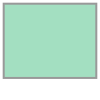

In [14]:
aoi_geom

In [44]:
geom = gpd.GeoSeries(aoi_geom, crs="EPSG:4326").to_crs(grid.crs)
aoi_grids = grid[grid.intersects(geom)]

/var/folders/9w/qrxsyfl53wq7drqbf6bj9gp00000gn/T/ipykernel_6922/528553430.py:2: UserWarning: The indices of the left and right GeoSeries' are not equal, and therefore they will be aligned (reordering and/or introducing missing values) before executing the operation. If this alignment is the desired behaviour, you can silence this warning by passing 'align=True'. If you don't want alignment and protect yourself of accidentally aligning, you can pass 'align=False'.
  aoi_grids = grid[grid.intersects(geom.geometry)]


In [59]:
type(list(aoi_grids["ll_tile"].values))

list

In [43]:
geom

0    POLYGON ((-5.79843 37.00621, -5.79843 37.45839...
dtype: geometry

In [15]:
tiles = grid[grid.intersects(aoi_geom)]
tiles

,ll_tile,geometry
1730,N36W009,"POLYGON ((-9 36, -9 39, -6 39, -6 36, -9 36))"
1732,N36W006,"POLYGON ((-6 36, -6 39, -3 39, -3 36, -6 36))"


In [16]:
tiles.geometry

1730    POLYGON ((-9 36, -9 39, -6 39, -6 36, -9 36))
1732    POLYGON ((-6 36, -6 39, -3 39, -3 36, -6 36))
Name: geometry, dtype: geometry

In [17]:
def get_worldcover_url(tile_id: str) -> str:
    """e.g. N36W006 → WorldCover S3 URL"""
    return (
        f"https://esa-worldcover.s3.amazonaws.com/v200/2021/map/"
        f"ESA_WorldCover_10m_2021_v200_{tile_id}_Map.tif"
    )

In [18]:
import rioxarray

url = get_worldcover_url("N36W009")

ds = rioxarray.open_rasterio(url)  # streams from S3, no download needed

In [34]:
aaa = ds.squeeze("band").isel(x=slice(None, None, 40), y=slice(None, None, 40))

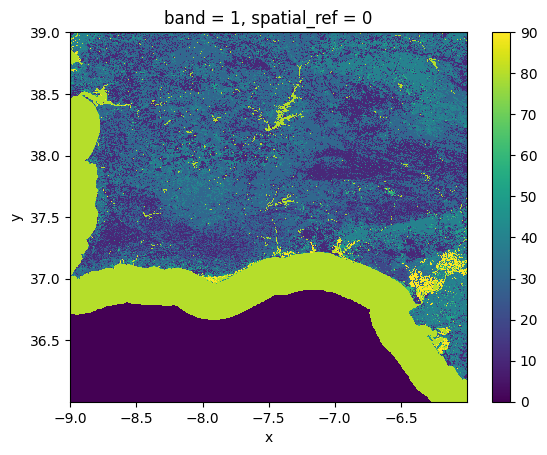

In [36]:
aaa.plot()

In [39]:
import numpy as np

In [41]:
np.unique(aaa)

array([ 0, 10, 20, 30, 40, 50, 60, 80, 90], dtype=uint8)

In [35]:
import os

In [28]:
parsed_url

ParseResult(scheme='https', netloc='esa-worldcover.s3.amazonaws.com', path='/v200/2021/map/ESA_WorldCover_10m_2021_v200_N36W009_Map.tif', params='', query='', fragment='')

In [29]:
filename = os.path.basename(parsed_url.path)

In [30]:
filename

'ESA_WorldCover_10m_2021_v200_N36W009_Map.tif'

In [51]:
raw = Path("../data/labels/worldcover_raw")

In [54]:
list(raw.glob("*.tif"))

[PosixPath('../data/labels/worldcover_raw/ESA_WorldCover_10m_2021_v200_N36W009_Map.tif'),
 PosixPath('../data/labels/worldcover_raw/ESA_WorldCover_10m_2021_v200_N36W006_Map.tif')]